Virtual Acoustics and Immersive Audio Workshop - CCRMA Stanford University  
23.07.25 - Orchisama Das, Gloria Dal Santo
  
### L03: Artificial Reverberation with Delay Networks

In this assignment we will 
- Create a Feedback Delay Network
- Generate various orthogonal feedback matrices: identity, random orthogonal, Hadamard, Householder (See [Table](https://dafx2020.mdw.ac.at/proceedings/papers/DAFx2020_paper_53.pdf)).
- Implement time-domain processing for mono input/output with any number of delay lines.
- Process the anechoic signals from Assignment 2 with the FDN. Use an impulse to hear the impulse response.
- Modify FDN parameters and size; observe and listen to how they affect the output.

In [ ]:
#pip install flamo   
#pip install torch

In [1]:
import sys
import os

# 获取当前notebook所在的目录
notebooks_dir = os.getcwd()
# 获取上一级目录（也就是项目的主文件夹）
project_root = os.path.dirname(notebooks_dir)
# 构建src文件夹的绝对路径
src_path = os.path.join(project_root, 'src')

# 如果src路径不在Python的搜索路径中，就添加进去
if src_path not in sys.path:
    sys.path.append(src_path)

# --- 现在您可以正常执行您原来的导入代码了 ---

import numpy as np
import IPython.display as ipd
from pathlib import Path

# 这次导入将会成功
from room_acoustics.fdn import FeedbackDelayNetwork
from utils import audioread
from room_acoustics.plot import plot_time_domain

print("路径问题已解决，模块导入成功！")

OSError: cannot load library '/Users/yiyi/Documents/VAIAWorkshop25Public/.venv/lib/python3.11/site-packages/_soundfile_data/libsndfile.dylib': dlopen(/Users/yiyi/Documents/VAIAWorkshop25Public/.venv/lib/python3.11/site-packages/_soundfile_data/libsndfile.dylib, 0x0002): tried: '/Users/yiyi/Documents/VAIAWorkshop25Public/.venv/lib/python3.11/site-packages/_soundfile_data/libsndfile.dylib' (no such file).  Additionally, ctypes.util.find_library() did not manage to locate a library called '/Users/yiyi/Documents/VAIAWorkshop25Public/.venv/lib/python3.11/site-packages/_soundfile_data/libsndfile.dylib'

In [8]:
# --- 导入 ---
# 讲解：和前两天一样，我们首先准备好今天“电路设计”所需的各种“元器件”（库和模块）。
# 今天的核心是一个我们自己编写的类 `FeedbackDelayNetwork`。

import numpy as np
# 讲解：科学计算库NumPy，它将负责处理所有底层的数学运算，比如向量、矩阵的乘法和加法，这些都是FDN算法的核心。

import IPython.display as ipd
# 讲解：我们的“试听工具”，用于创建音频播放器，方便我们随时用耳朵来检验自己设计的混响效果好不好听。

from pathlib import Path
# 讲解：文件路径处理工具，帮助我们以可靠的方式读取音频文件。

from room_acoustics.fdn import FeedbackDelayNetwork
# 讲解：⭐ 今日主角！我们从 `room_acoustics/fdn.py` 文件中，导入一个名为 `FeedbackDelayNetwork` 的类 (Class)。
# “类”可以理解为一个“设计蓝图”，今天我们的核心任务就是根据这份蓝图，创建出（实例化）一个功能完整的FDN混响器，并调整它的各种参数。

from utils import audioread
# 讲解：从我们的老朋友 `utils.py` 中导入音频读取函数。

from room_acoustics.plot import plot_time_domain
# 讲解：导入时域波形图的绘制函数，方便我们观察生成的混响脉冲响应（RIR）长什么样。

#### 1. Create a Feedback Delay Network

Head to `room_acoustics.fdn`, you will find a partially coded class `FeedbackDelayNetwork`. You will have to
- 1.1 Complete the `get_feedback_matrix` method that generates the feedback matrix based on the specified type. 
- 1.2 Complete the `process` function that perform time domain processing of an input signal through the FDN
- 1.3 In the cell below, generate and impulse signal and process it with the FDN to obtain the synthetic RIR. 
- 1.4 Process the dry signals `data/Drums.wav`, `data/Sax.wav`, and `data/Speech.wav`. 

/Users/yiyi/Documents/VAIAWorkshop25Public/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yiyi/Documents/VAIAWorkshop25Public/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33033 (\N{CJK UNIFIED IDEOGRAPH-8109}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yiyi/Documents/VAIAWorkshop25Public/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20914 (\N{CJK UNIFIED IDEOGRAPH-51B2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yiyi/Documents/VAIAWorkshop25Public/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21709 (\N{CJK UNIFIED IDEOGRAPH-54CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yiyi/Documents/VA

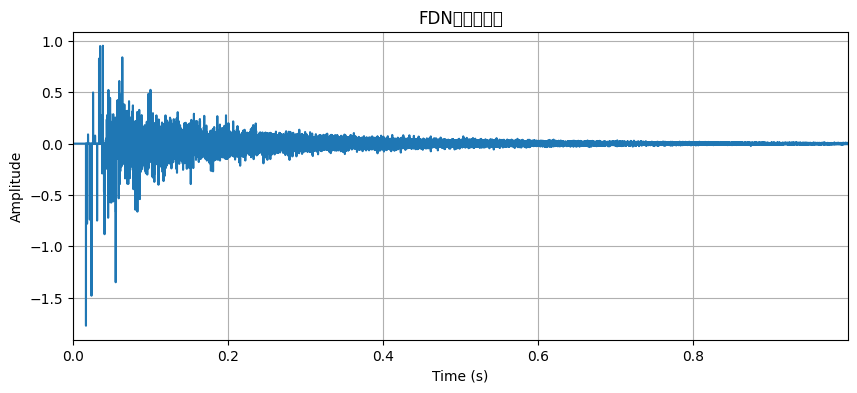

In [17]:
# --- 第二步：生成并试听FDN的脉冲响应 ---
# 讲解：现在我们将使用上一节导入的 `FeedbackDelayNetwork` 蓝图，
# 来“实例化”或者说“建造”一个我们自己设计的混响效果器。
# 然后，我们会输入一个最简单的信号——一个脉冲（Impulse）——来听一下这个效果器自身的“声学指纹”，也就是它的脉冲响应（RIR）。

# --- 1. 设置采样率 ---
fs = 48000
# 讲解：定义我们系统的工作采样率。所有时间相关的参数（如延时长度、T60）都依赖于它。

# --- 2. 实例化并配置FDN对象 ---
# 讲解：这是最核心的一步。我们调用 `FeedbackDelayNetwork(...)` 来创建一个混响器实例，并设置其关键参数。
# `fdn` 现在就是一个功能完整的混响效果器对象了。
fdn = FeedbackDelayNetwork(
    # `sample_rate`: 告诉FDN我们的工作采样率是48kHz。
    sample_rate = fs,
    # `delay_lengths`: ⭐ 这是FDN的心脏！它是一个列表，定义了FDN内部有多少条延时线，以及每一条的长度（单位是采样点）。
    # 这里的数值都是精心挑选的互为质数的数字，这样可以避免产生不良的周期性回声，让混响更平滑。
    delay_lengths=[809, 877, 937, 1049, 1151, 1249, 1373, 1499],
    # `feedback_matrix_type`: 定义了延时线之间信号是如何混合的。
    # 'random' 会创建一个随机的“混合矩阵”，这是一种简单有效的方式来创造扩散感良好的混响。
    feedback_matrix_type='random',
    # `t60`: 我们期望的混响时间。在这里，我们希望设计一个混响时间为2.0秒的效果器。
    # FDN内部会根据这个值自动计算出合适的反馈增益。
    t60 = 2.0
)

# --- 3. 创建一个脉冲信号 ---
# 讲解：为了听到FDN自身的脉冲响应，我们需要一个“脉冲”作为输入信号。
# 在数字世界里，最完美的脉冲就是一个值为1.0的采样点，其余所有采样点都为0。
# 代码含义：
# `np.zeros((fs, ))`: 创建一个长度为1秒（fs个采样点）的、所有值都为0的数组。
input_signal = np.zeros((fs, ))
# `input_signal[0] = 1.0`: 将第一个采样点的值设为1.0。
input_signal[0] = 1.0

# --- 4. 处理信号 ---
# 讲解：我们将脉冲信号“喂”给FDN进行处理。
# `fdn.process(...)` 是一个方法（method），它会执行FDN的整个算法，并将处理后的结果存储在`fdn.output`中。
fdn.process(input_signal)

# --- 5. 可视化与试听 ---
# 讲解：现在 `fdn.output` 中存储的就是我们设计的这个FDN的脉冲响应了。
# 我们可以将它绘制出来，并用耳朵听一下它的声音。
plot_time_domain(fdn.output, fs=fs, title='FDN的脉冲响应')
ipd.display(ipd.Audio(fdn.output, rate=fs))

# 听感结论：
# 您听到的声音就是一个具有扩散感和2秒钟衰减时长的混响尾音。
# 这就是我们刚刚用代码设计的这个“虚拟空间”的声音特性。
# 接下来，我们将通过改变FDN的参数，来探索如何改变这个声音的特性。

#### 2. Process Anechoic Signals 

Process the dry signals `data/Drums.wav`, `data/Sax.wav`, and `data/Speech.wav`. 

In [18]:
# --- 第三步：用FDN处理干声 ---
# 讲解：现在我们进入了“应用”环节。我们不再输入简单的脉冲，
# 而是将一些真实的、在无响室录制的“干声”（鼓、萨克斯、人声）
# 输入到我们刚刚设计的FDN混响器中，来听一下最终的“加湿”效果。
# 这就完全模拟了您在混音工作时，给一个音轨添加混响插件的过程。

# --- 定义要处理的干声文件名列表 ---
anechoic = ['Drums', 'Sax', 'Speech']

# --- 循环处理每一个干声文件 ---
# 讲解：这是一个循环（for loop），它会依次取出列表中的每一个文件名（'Drums', 'Sax', 'Speech'），
# 并对它们执行下面缩进代码块中的所有操作。
for filename in anechoic:
    # 1. 加载音频文件
    rec_path = Path('..') / 'data' / 'Week 1' / f'{filename}.wav'
    rec, fs = audioread(str(rec_path))

    # 2. 用同一个FDN处理当前的干声音频
    # 讲解：这是核心操作。我们调用之前创建的 `fdn` 对象的 `process` 方法。
    # `fdn` 仍然保持着我们之前设定的所有参数（2.0秒的T60，随机反馈矩阵等）。
    # `process` 方法会用这些参数来处理输入的 `rec`（录音）信号。
    fdn.process(rec)

    # 3. 打印文件名并创建播放器
    print(f"{filename}")
    # 播放 `fdn.output` 中存储的、已经加上了混响效果的声音。
    ipd.display(ipd.Audio(fdn.output, rate=fs))

# --- 听感结论 (注释形式) ---
#
# 听感指南：
# - **一致性**: 请注意，无论输入的是鼓、萨克斯还是人声，它们最终都被赋予了“同一种”空间感。
#   这个空间感就是由我们设计的FDN的特性所决定的（2.0秒的衰减，平滑的混响尾音等）。
# - **音色变化**: 观察FDN是如何影响不同声音的。例如，对于像鼓这样有瞬态的信号，
#   您可以清晰地听到混响是如何在每次敲击后“绽放”开来的。对于像萨克斯这样有延音的乐器，
#   混响则会与乐器本身的声音更紧密地融合在一起。
# 这个练习的目的，是让您直观地感受到一个参数固定的数字混响算法，是如何为不同的声源统一添加空间特性的。

Drums


Sax


Speech


#### 3. Try different parameters! 

You can try different combinations of parameters: 
- Change the size of the FDN. What is a good sounding size? 
- Change the type of feedback matrix and the length of the delay lines.
- If you have time, you can try to implement a simple first order low pass filer instead of the homogenous loss. 

--- 正在创建使用 'Good' 延时组合的FDN ---
试听 'Good' FDN 的脉冲响应:


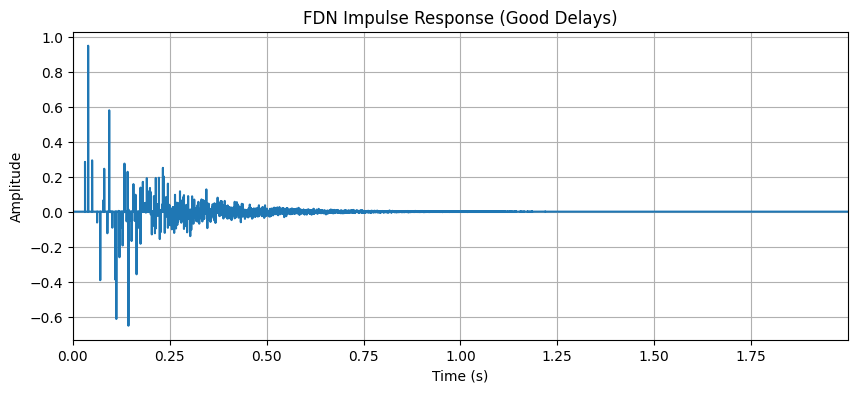


--- 正在创建使用 'Bad' 延时组合的FDN ---
试听 'Bad' FDN 的脉冲响应:


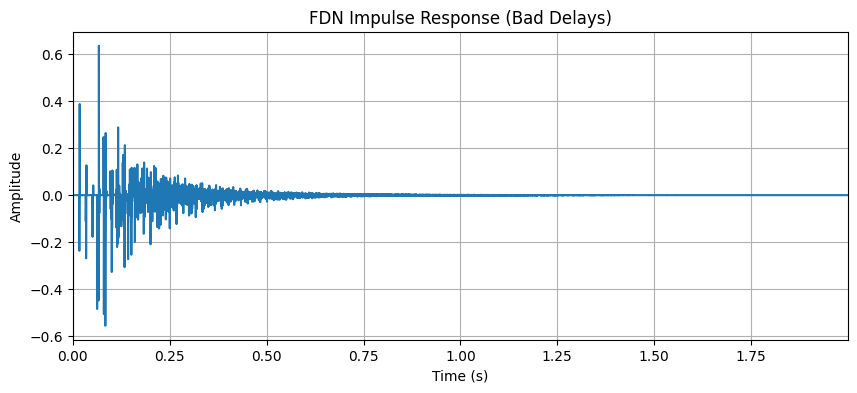

In [19]:
# --- 实验：对比“好”与“差”的FDN延时长度 ---

import numpy as np
import IPython.display as ipd
from room_acoustics.fdn import FeedbackDelayNetwork
from room_acoustics.plot import plot_time_domain

# --- 1. 定义基本参数 ---
fs = 48000  # 采样率
t60 = 1.5   # 我们期望的混响时间

# --- 2. 使用 "Good" 延时组合 (以N=4为例) ---
print("--- 正在创建使用 'Good' 延时组合的FDN ---")
good_delays = [1499, 1889, 2381, 2999]  # 来自表格 
fdn_good = FeedbackDelayNetwork(
    sample_rate=fs,
    delay_lengths=good_delays,
    feedback_matrix_type='random',  # 保持其他参数一致
    t60=t60
)

# 创建脉冲信号
impulse = np.zeros((fs * 2, ))  # 创建2秒长的静音
impulse[0] = 1.0

# 处理信号并试听
fdn_good.process(impulse)
print("试听 'Good' FDN 的脉冲响应:")
plot_time_domain(fdn_good.output, fs=fs, title='FDN Impulse Response (Good Delays)')
ipd.display(ipd.Audio(fdn_good.output, rate=fs))


# --- 3. 使用 "Bad" 延时组合 (以N=4为例) ---
print("\n--- 正在创建使用 'Bad' 延时组合的FDN ---")
bad_delays = [797, 839, 2381, 2999]  # 来自表格 
fdn_bad = FeedbackDelayNetwork(
    sample_rate=fs,
    delay_lengths=bad_delays,
    feedback_matrix_type='random',  # 保持其他参数一致
    t60=t60
)

# 处理信号并试听
fdn_bad.process(impulse)
print("试听 'Bad' FDN 的脉冲响应:")
plot_time_domain(fdn_bad.output, fs=fs, title='FDN Impulse Response (Bad Delays)')
ipd.display(ipd.Audio(fdn_bad.output, rate=fs))

# --- 4. 结论 ---
# 听觉对比会非常明显：
# - 'Good' FDN的声音会是平滑、均匀扩散的混响。
# - 'Bad' FDN的声音可能会带有明显的音调感或金属质感，这是因为相近的延时长度导致了梳状滤波效应。
# 这个实验直观地证明了在设计FDN时，精心选择互为质数且对数分布的延时长度是至关重要的。